The initial (failed) implementation of our Hebbian MLP learners.
Note the vanilla Hebbian implementation is a refactor of an existing implementation from Lv et al. while the GD implementation is borrowed from Diego's existing codebase.

In [ ]:

# If Colab import issues arise, uncomment the next line.
# !pip -q install torch torchvision pandas nilearn nibabel scikit-learn

import math
import random
import time
from dataclasses import dataclass, asdict
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, TensorDataset, Subset
from torchvision import datasets, transforms

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

try:
    from nilearn import datasets as nilearn_datasets
    from nilearn.maskers import NiftiMasker
    HAXBY_AVAILABLE = True
except Exception:
    HAXBY_AVAILABLE = False

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cpu


In [ ]:

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def make_image_datasets(name: str, root: str = "./data"):
    name = name.lower()
    if name == "mnist":
        transform = transforms.Compose([
            transforms.ToTensor(),
        ])
        train_ds = datasets.MNIST(root=root, train=True, download=True, transform=transform)
        test_ds = datasets.MNIST(root=root, train=False, download=True, transform=transform)
        input_dim = 28 * 28
        num_classes = 10
    elif name == "cifar100":
        transform = transforms.Compose([
            transforms.ToTensor(),
        ])
        train_ds = datasets.CIFAR100(root=root, train=True, download=True, transform=transform)
        test_ds = datasets.CIFAR100(root=root, train=False, download=True, transform=transform)
        input_dim = 32 * 32 * 3
        num_classes = 100
    else:
        raise ValueError(f"Unknown dataset: {name}")
    return train_ds, test_ds, input_dim, num_classes


def make_image_loaders(name: str, batch_size: int = 128, train_subset: int | None = None, test_subset: int | None = None, root: str = "./data"):
    train_ds, test_ds, input_dim, num_classes = make_image_datasets(name, root=root)
    if train_subset is not None:
        train_ds = Subset(train_ds, list(range(min(train_subset, len(train_ds)))))
    if test_subset is not None:
        test_ds = Subset(test_ds, list(range(min(test_subset, len(test_ds)))))

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    return train_loader, test_loader, input_dim, num_classes


class MLP(nn.Module):
    def __init__(self, input_dim: int, hidden_dims: list[int], output_dim: int):
        super().__init__()
        self.hidden_layers = nn.ModuleList()
        dims = [input_dim] + hidden_dims
        for din, dout in zip(dims[:-1], dims[1:]):
            layer = nn.Linear(din, dout, bias=False)
            nn.init.normal_(layer.weight, mean=0.0, std=0.02)
            self.hidden_layers.append(layer)

        self.out = nn.Linear(hidden_dims[-1], output_dim)
        nn.init.normal_(self.out.weight, mean=0.0, std=0.02)
        nn.init.zeros_(self.out.bias)

    def features(self, x: torch.Tensor):
        x = x.view(x.size(0), -1)
        pres = []
        posts = []
        h = x
        for layer in self.hidden_layers:
            pres.append(h)
            h = F.relu(layer(h))
            posts.append(h)
        return h, pres, posts

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h, _, _ = self.features(x)
        return self.out(h)


In [ ]:

@dataclass
class RuleState:
    prev_act: torch.Tensor
    gate_trace: torch.Tensor


@dataclass
class RunMetrics:
    dataset: str
    rule: str
    seed: int
    fold: int | None
    final_test_accuracy: float
    best_test_accuracy: float
    train_accuracy: float
    unstable: bool
    nan_encountered: bool
    max_hidden_weight_norm: float
    max_readout_weight_norm: float
    max_update_norm: float
    min_train_loss: float
    final_train_loss: float
    mean_gate: float | None = None
    gate_saturation_frac: float | None = None


def init_rule_states(model: MLP, device: torch.device):
    states = []
    for layer in model.hidden_layers:
        out_dim = layer.weight.shape[0]
        states.append(
            RuleState(
                prev_act=torch.zeros(out_dim, device=device),
                gate_trace=torch.zeros(out_dim, device=device),
            )
        )
    return states


In [ ]:

def update_hidden_layers_local(
    model: MLP,
    pre_acts: list[torch.Tensor],
    post_acts: list[torch.Tensor],
    states: list[RuleState],
    rule: str,
    lr_hidden: float,
    alpha: float,
    g_max: float,
    oja_decay: float,
):
    gate_means = []
    gate_sats = []
    max_update_norm = 0.0

    with torch.no_grad():
        for i, layer in enumerate(model.hidden_layers):
            pre = pre_acts[i]
            post = post_acts[i]
            state = states[i]

            hebb = post.t() @ pre / pre.shape[0]
            post_sq = post.pow(2).mean(dim=0).unsqueeze(1)
            delta = hebb - oja_decay * post_sq * layer.weight.data

            if rule == "hebbian":
                g = torch.ones(post.shape[1], device=post.device)
            elif rule == "accel_gate":
                current = post.mean(dim=0)
                rise = torch.relu(current - state.prev_act)
                state.gate_trace = alpha * state.gate_trace + (1.0 - alpha) * rise
                g = torch.clamp(state.gate_trace, 0.0, g_max)
                state.prev_act = current.detach()
                gate_means.append(float(g.mean().item()))
                gate_sats.append(float((g >= g_max - 1e-8).float().mean().item()))
            elif rule == "magnitude_gate":
                current = post.mean(dim=0)
                state.gate_trace = alpha * state.gate_trace + (1.0 - alpha) * current
                g = torch.clamp(state.gate_trace, 0.0, g_max)
                state.prev_act = current.detach()
                gate_means.append(float(g.mean().item()))
                gate_sats.append(float((g >= g_max - 1e-8).float().mean().item()))
            else:
                raise ValueError(f"Unknown rule: {rule}")

            if rule != "hebbian":
                delta = g.unsqueeze(1) * delta

            update = lr_hidden * delta
            max_update_norm = max(max_update_norm, float(update.norm().item()))
            layer.weight.data.add_(update)

            norms = layer.weight.data.norm(dim=1, keepdim=True).clamp_min(1e-8)
            layer.weight.data.div_(norms)

    mean_gate = float(np.mean(gate_means)) if gate_means else None
    sat_gate = float(np.mean(gate_sats)) if gate_sats else None
    return mean_gate, sat_gate, max_update_norm


In [ ]:

@torch.no_grad()
def evaluate_model(model: MLP, loader: DataLoader, device: torch.device):
    model.eval()
    total = 0
    correct = 0
    total_loss = 0.0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        logits = model(xb)
        loss = F.cross_entropy(logits, yb, reduction="sum")
        total_loss += float(loss.item())
        correct += int((logits.argmax(dim=1) == yb).sum().item())
        total += yb.size(0)

    return total_loss / max(total, 1), correct / max(total, 1)


def train_one_run_from_loaders(
    *,
    dataset_name: str,
    rule: str,
    seed: int,
    train_loader: DataLoader,
    test_loader: DataLoader,
    input_dim: int,
    num_classes: int,
    device: torch.device,
    hidden_dims: list[int],
    fold: int | None = None,
    epochs: int = 5,
    lr_hidden: float = 0.01,
    lr_out: float = 0.05,
    alpha: float = 0.9,
    g_max: float = 1.0,
    oja_decay: float = 0.1,
    momentum: float = 0.9,
    log_every: int = 1,
):
    set_seed(seed)
    model = MLP(input_dim, hidden_dims, num_classes).to(device)

    unstable = False
    nan_encountered = False
    max_hidden_weight_norm = 0.0
    max_readout_weight_norm = 0.0
    max_update_norm = 0.0
    min_train_loss = math.inf
    final_train_loss = math.inf
    best_test_acc = 0.0
    last_gate_mean = None
    last_gate_sat = None

    if rule == "backprop":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr_out, momentum=momentum)
        rule_states = None
    else:
        optimizer = torch.optim.SGD(model.out.parameters(), lr=lr_out, momentum=momentum)
        rule_states = init_rule_states(model, device)

    batch_rows = []
    eval_rows = []
    global_step = 0
    t0 = time.perf_counter()

    for epoch in range(epochs):
        model.train()
        epoch_loss_sum = 0.0
        epoch_count = 0
        epoch_correct = 0

        for xb, yb in train_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)

            feats, pres, posts = model.features(xb)
            logits = model.out(feats)
            loss = F.cross_entropy(logits, yb)

            if torch.isnan(loss) or torch.isinf(loss):
                nan_encountered = True
                unstable = True
                break

            if rule == "backprop":
                loss.backward()
                optimizer.step()
                local_update_norm = 0.0
                last_gate_mean = None
                last_gate_sat = None
            else:
                loss.backward()
                optimizer.step()
                last_gate_mean, last_gate_sat, local_update_norm = update_hidden_layers_local(
                    model=model,
                    pre_acts=[p.detach().view(p.size(0), -1) for p in pres],
                    post_acts=[p.detach() for p in posts],
                    states=rule_states,
                    rule=rule,
                    lr_hidden=lr_hidden,
                    alpha=alpha,
                    g_max=g_max,
                    oja_decay=oja_decay,
                )
                max_update_norm = max(max_update_norm, local_update_norm)

            global_step += 1
            elapsed = time.perf_counter() - t0
            batch_loss = float(loss.item())
            batch_acc = float((logits.argmax(dim=1) == yb).float().mean().item())

            hidden_norm = max(float(layer.weight.data.norm().item()) for layer in model.hidden_layers)
            out_norm = float(model.out.weight.data.norm().item())
            max_hidden_weight_norm = max(max_hidden_weight_norm, hidden_norm)
            max_readout_weight_norm = max(max_readout_weight_norm, out_norm)

            if not np.isfinite(hidden_norm) or not np.isfinite(out_norm):
                unstable = True
                nan_encountered = True
                break
            if hidden_norm > 1e4 or out_norm > 1e4:
                unstable = True
                break

            epoch_loss_sum += batch_loss * yb.size(0)
            epoch_count += yb.size(0)
            epoch_correct += int((logits.argmax(dim=1) == yb).sum().item())

            if global_step % log_every == 0:
                batch_rows.append({
                    "dataset": dataset_name,
                    "rule": rule,
                    "seed": seed,
                    "fold": fold,
                    "epoch": epoch + 1,
                    "step": global_step,
                    "elapsed_sec": elapsed,
                    "batch_loss": batch_loss,
                    "batch_nll": batch_loss,
                    "batch_acc": batch_acc,
                    "hidden_weight_norm": hidden_norm,
                    "readout_weight_norm": out_norm,
                    "update_norm": local_update_norm,
                    "mean_gate": last_gate_mean,
                    "gate_saturation_frac": last_gate_sat,
                })

        if nan_encountered:
            break

        final_train_loss = epoch_loss_sum / max(epoch_count, 1)
        min_train_loss = min(min_train_loss, final_train_loss)
        train_acc_epoch = epoch_correct / max(epoch_count, 1)
        train_loss_full, train_acc_full = evaluate_model(model, train_loader, device)
        test_loss_full, test_acc_full = evaluate_model(model, test_loader, device)
        best_test_acc = max(best_test_acc, test_acc_full)
        elapsed = time.perf_counter() - t0

        eval_rows.append({
            "dataset": dataset_name,
            "rule": rule,
            "seed": seed,
            "fold": fold,
            "epoch": epoch + 1,
            "step": global_step,
            "elapsed_sec": elapsed,
            "train_loss": train_loss_full,
            "train_nll": train_loss_full,
            "train_acc": train_acc_full,
            "test_loss": test_loss_full,
            "test_nll": test_loss_full,
            "test_acc": test_acc_full,
            "best_test_acc_so_far": best_test_acc,
            "hidden_weight_norm": max(float(layer.weight.data.norm().item()) for layer in model.hidden_layers),
            "readout_weight_norm": float(model.out.weight.data.norm().item()),
            "max_update_norm_so_far": max_update_norm,
            "mean_gate": last_gate_mean,
            "gate_saturation_frac": last_gate_sat,
        })

        if unstable:
            break

    train_loss, train_acc = evaluate_model(model, train_loader, device)
    test_loss, test_acc = evaluate_model(model, test_loader, device)

    metrics = RunMetrics(
        dataset=dataset_name,
        rule=rule,
        seed=seed,
        fold=fold,
        final_test_accuracy=test_acc,
        best_test_accuracy=best_test_acc,
        train_accuracy=train_acc,
        unstable=unstable,
        nan_encountered=nan_encountered,
        max_hidden_weight_norm=max_hidden_weight_norm,
        max_readout_weight_norm=max_readout_weight_norm,
        max_update_norm=max_update_norm,
        min_train_loss=min_train_loss,
        final_train_loss=train_loss,
        mean_gate=last_gate_mean,
        gate_saturation_frac=last_gate_sat,
    )

    return metrics, pd.DataFrame(batch_rows), pd.DataFrame(eval_rows)


In [ ]:

def summarise_final_metrics(metrics_df: pd.DataFrame) -> pd.DataFrame:
    out = (
        metrics_df
        .groupby(["dataset", "rule"], as_index=False)
        .agg(
            mean_final_test_accuracy=("final_test_accuracy", "mean"),
            std_final_test_accuracy=("final_test_accuracy", "std"),
            mean_best_test_accuracy=("best_test_accuracy", "mean"),
            unstable_fraction=("unstable", "mean"),
            nan_fraction=("nan_encountered", "mean"),
            mean_max_hidden_weight_norm=("max_hidden_weight_norm", "mean"),
            mean_max_readout_weight_norm=("max_readout_weight_norm", "mean"),
            mean_max_update_norm=("max_update_norm", "mean"),
            mean_final_train_loss=("final_train_loss", "mean"),
            mean_gate=("mean_gate", "mean"),
            mean_gate_saturation_frac=("gate_saturation_frac", "mean"),
        )
        .sort_values(["dataset", "mean_final_test_accuracy"], ascending=[True, False])
        .reset_index(drop=True)
    )
    return out


def _aggregate_mean_std(df: pd.DataFrame, group_cols: list[str], value_cols: list[str]) -> pd.DataFrame:
    agg = df.groupby(group_cols, as_index=False)[value_cols].agg(["mean", "std"])
    agg.columns = ["_".join([c for c in col if c]).rstrip("_") for col in agg.columns.to_flat_index()]
    return agg


def plot_learning_analysis(dataset_name: str, batch_df: pd.DataFrame, eval_df: pd.DataFrame, include_gate_plots: bool = True):
    batch_sub = batch_df[batch_df["dataset"] == dataset_name].copy()
    eval_sub = eval_df[eval_df["dataset"] == dataset_name].copy()
    if len(batch_sub) == 0 and len(eval_sub) == 0:
        print(f"No history found for {dataset_name}")
        return

    # 1. Train and test NLL versus epoch
    if len(eval_sub) > 0:
        agg_eval = (
            eval_sub.groupby(["rule", "epoch"], as_index=False)
            .agg(
                train_nll_mean=("train_nll", "mean"),
                train_nll_std=("train_nll", "std"),
                test_nll_mean=("test_nll", "mean"),
                test_nll_std=("test_nll", "std"),
                test_acc_mean=("test_acc", "mean"),
                test_acc_std=("test_acc", "std"),
                elapsed_mean=("elapsed_sec", "mean"),
                elapsed_std=("elapsed_sec", "std"),
            )
        )

        plt.figure(figsize=(8, 5))
        for rule in agg_eval["rule"].unique():
            part = agg_eval[agg_eval["rule"] == rule]
            plt.plot(part["epoch"], part["train_nll_mean"], label=f"{rule} train")
            plt.plot(part["epoch"], part["test_nll_mean"], linestyle="--", label=f"{rule} test")
        plt.xlabel("Epoch")
        plt.ylabel("Negative log-likelihood / cross-entropy")
        plt.title(f"{dataset_name}: loss minimisation over training")
        plt.legend()
        plt.tight_layout()
        plt.show()

        # 2. Accuracy versus epoch
        plt.figure(figsize=(8, 5))
        for rule in agg_eval["rule"].unique():
            part = agg_eval[agg_eval["rule"] == rule]
            plt.plot(part["epoch"], part["test_acc_mean"], label=rule)
        plt.xlabel("Epoch")
        plt.ylabel("Test accuracy")
        plt.title(f"{dataset_name}: test accuracy over training")
        plt.legend()
        plt.tight_layout()
        plt.show()

        # 3. Accuracy versus wall-clock time
        plt.figure(figsize=(8, 5))
        for rule in agg_eval["rule"].unique():
            part = agg_eval[agg_eval["rule"] == rule]
            plt.plot(part["elapsed_mean"], part["test_acc_mean"], label=rule)
        plt.xlabel("Wall-clock time (seconds)")
        plt.ylabel("Test accuracy")
        plt.title(f"{dataset_name}: accuracy as a function of wall-clock time")
        plt.legend()
        plt.tight_layout()
        plt.show()

    if len(batch_sub) > 0:
        agg_batch = (
            batch_sub.groupby(["rule", "step"], as_index=False)
            .agg(
                batch_nll_mean=("batch_nll", "mean"),
                hidden_weight_norm_mean=("hidden_weight_norm", "mean"),
                update_norm_mean=("update_norm", "mean"),
                mean_gate_mean=("mean_gate", "mean"),
                gate_saturation_frac_mean=("gate_saturation_frac", "mean"),
                elapsed_mean=("elapsed_sec", "mean"),
            )
        )

        # 4. Stability: hidden weight norm versus iterate
        plt.figure(figsize=(8, 5))
        for rule in agg_batch["rule"].unique():
            part = agg_batch[agg_batch["rule"] == rule]
            plt.plot(part["step"], part["hidden_weight_norm_mean"], label=rule)
        plt.xlabel("Training step")
        plt.ylabel("Hidden weight norm")
        plt.title(f"{dataset_name}: stability via hidden weight norms")
        plt.legend()
        plt.tight_layout()
        plt.show()

        # 5. Stability: update norm versus iterate
        plt.figure(figsize=(8, 5))
        for rule in agg_batch["rule"].unique():
            part = agg_batch[agg_batch["rule"] == rule]
            plt.plot(part["step"], part["update_norm_mean"], label=rule)
        plt.xlabel("Training step")
        plt.ylabel("Update norm")
        plt.title(f"{dataset_name}: update size as a function of iterate")
        plt.legend()
        plt.tight_layout()
        plt.show()

        if include_gate_plots:
            gated = agg_batch[agg_batch["rule"].isin(["accel_gate", "magnitude_gate"])]
            if len(gated) > 0:
                plt.figure(figsize=(8, 5))
                for rule in gated["rule"].unique():
                    part = gated[gated["rule"] == rule]
                    plt.plot(part["step"], part["mean_gate_mean"], label=rule)
                plt.xlabel("Training step")
                plt.ylabel("Mean gate value")
                plt.title(f"{dataset_name}: gate activity over training")
                plt.legend()
                plt.tight_layout()
                plt.show()

                plt.figure(figsize=(8, 5))
                for rule in gated["rule"].unique():
                    part = gated[gated["rule"] == rule]
                    plt.plot(part["step"], part["gate_saturation_frac_mean"], label=rule)
                plt.xlabel("Training step")
                plt.ylabel("Gate saturation fraction")
                plt.title(f"{dataset_name}: gate saturation over training")
                plt.legend()
                plt.tight_layout()
                plt.show()



## Image experiments: configuration

Use the subset sizes below for a quick Colab pass. Set the subset sizes to `None` for fuller runs.


In [ ]:

rules = ["hebbian", "accel_gate", "magnitude_gate", "backprop"]
seeds = [0, 1, 2]

image_config = {
    "mnist": {
        "train_subset": 12000,
        "test_subset": 2000,
        "epochs": 5,
        "batch_size": 128,
        "hidden_dims": [1024, 256],
        "lr_hidden": 0.01,
        "lr_out": 0.05,
        "alpha": 0.9,
        "g_max": 1.0,
        "oja_decay": 0.1,
        "momentum": 0.9,
        "log_every": 5,
    },
    "cifar100": {
        "train_subset": 15000,
        "test_subset": 3000,
        "epochs": 8,
        "batch_size": 128,
        "hidden_dims": [1024, 256],
        "lr_hidden": 0.005,
        "lr_out": 0.05,
        "alpha": 0.9,
        "g_max": 1.0,
        "oja_decay": 0.1,
        "momentum": 0.9,
        "log_every": 10,
    },
}


In [ ]:

all_metrics = []
all_batch_histories = []
all_eval_histories = []

for dataset_name in ["mnist", "cifar100"]:
    cfg = image_config[dataset_name]
    print(f"===== DATASET: {dataset_name} =====")
    train_loader, test_loader, input_dim, num_classes = make_image_loaders(
        dataset_name,
        batch_size=cfg["batch_size"],
        train_subset=cfg["train_subset"],
        test_subset=cfg["test_subset"],
    )

    for rule in rules:
        for seed in seeds:
            metrics, batch_df, eval_df = train_one_run_from_loaders(
                dataset_name=dataset_name,
                rule=rule,
                seed=seed,
                train_loader=train_loader,
                test_loader=test_loader,
                input_dim=input_dim,
                num_classes=num_classes,
                device=device,
                hidden_dims=cfg["hidden_dims"],
                fold=None,
                epochs=cfg["epochs"],
                lr_hidden=cfg["lr_hidden"],
                lr_out=cfg["lr_out"],
                alpha=cfg["alpha"],
                g_max=cfg["g_max"],
                oja_decay=cfg["oja_decay"],
                momentum=cfg["momentum"],
                log_every=cfg["log_every"],
            )
            all_metrics.append(asdict(metrics))
            if len(batch_df) > 0:
                all_batch_histories.append(batch_df)
            if len(eval_df) > 0:
                all_eval_histories.append(eval_df)
            print(asdict(metrics))

metrics_df = pd.DataFrame(all_metrics)
batch_history_df = pd.concat(all_batch_histories, ignore_index=True) if all_batch_histories else pd.DataFrame()
eval_history_df = pd.concat(all_eval_histories, ignore_index=True) if all_eval_histories else pd.DataFrame()


===== DATASET: mnist =====


100%|██████████| 9.91M/9.91M [00:00<00:00, 39.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.12MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.4MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'dataset': 'mnist', 'rule': 'hebbian', 'seed': 0, 'fold': None, 'final_test_accuracy': 0.1035, 'best_test_accuracy': 0.1095, 'train_accuracy': 0.10233333333333333, 'unstable': False, 'nan_encountered': False, 'max_hidden_weight_norm': 32.00031661987305, 'max_readout_weight_norm': 1033.1240234375, 'max_update_norm': 5823.29833984375, 'min_train_loss': 416468.4164409841, 'final_train_loss': 315562.38916666666, 'mean_gate': None, 'gate_saturation_frac': None}
{'dataset': 'mnist', 'rule': 'hebbian', 'seed': 1, 'fold': None, 'final_test_accuracy': 0.1085, 'best_test_accuracy': 0.1085, 'train_accuracy': 0.09866666666666667, 'unstable': False, 'nan_encountered': False, 'max_hidden_weight_norm': 32.00056457519531, 'max_readout_weight_norm': 1002.1337890625, 'max_update_norm': 5729.333984375, 'min_train_loss': 374795.943814298, 'final_train_loss': 722078.412, 'mean_gate': None, 'gate_saturation_frac': None}
{'dataset': 'mnist', 'rule': 'hebbian', 'seed': 2, 'fold': None, 'final_test_accuracy':

100%|██████████| 169M/169M [07:49<00:00, 360kB/s]


{'dataset': 'cifar100', 'rule': 'hebbian', 'seed': 0, 'fold': None, 'final_test_accuracy': 0.012, 'best_test_accuracy': 0.012, 'train_accuracy': 0.010533333333333334, 'unstable': True, 'nan_encountered': False, 'max_hidden_weight_norm': 32.001121520996094, 'max_readout_weight_norm': 10488.8984375, 'max_update_norm': 42747.9609375, 'min_train_loss': 2165545.337526965, 'final_train_loss': 6969869.834666667, 'mean_gate': None, 'gate_saturation_frac': None}
{'dataset': 'cifar100', 'rule': 'hebbian', 'seed': 1, 'fold': None, 'final_test_accuracy': 0.011666666666666667, 'best_test_accuracy': 0.011666666666666667, 'train_accuracy': 0.009466666666666667, 'unstable': True, 'nan_encountered': False, 'max_hidden_weight_norm': 32.00065994262695, 'max_readout_weight_norm': 10416.7822265625, 'max_update_norm': 42593.46484375, 'min_train_loss': 2189232.1954734665, 'final_train_loss': 6889001.765333333, 'mean_gate': None, 'gate_saturation_frac': None}
{'dataset': 'cifar100', 'rule': 'hebbian', 'seed':

/tmp/ipykernel_21923/1903411449.py:45: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  batch_history_df = pd.concat(all_batch_histories, ignore_index=True) if all_batch_histories else pd.DataFrame()
/tmp/ipykernel_21923/1903411449.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  eval_history_df = pd.concat(all_eval_histories, ignore_index=True) if all_eval_histories else pd.DataFrame()


In [ ]:

summary_df = summarise_final_metrics(metrics_df)
display(summary_df)


,dataset,rule,mean_final_test_accuracy,std_final_test_accuracy,mean_best_test_accuracy,unstable_fraction,nan_fraction,mean_max_hidden_weight_norm,mean_max_readout_weight_norm,mean_max_update_norm,mean_final_train_loss,mean_gate,mean_gate_saturation_frac
0,cifar100,backprop,0.126778,0.001953,0.132333,0.0,0.0,38.023665,11.561517,0.000000,3.502538e+00,NaN,NaN
1,cifar100,hebbian,0.011111,0.001262,0.011111,1.0,0.0,32.000806,10372.678711,43037.865885,6.879494e+06,NaN,NaN
2,cifar100,magnitude_gate,0.009889,0.000962,0.009889,1.0,0.0,31.999971,10222.817383,30654.488281,6.454780e+06,0.689409,0.683919
3,cifar100,accel_gate,0.008444,0.001171,0.008444,1.0,0.0,31.999406,10083.939128,22495.848958,6.236736e+06,0.537363,0.428385
4,mnist,backprop,0.933500,0.004583,0.933500,0.0,0.0,19.464507,6.315398,0.000000,7.235242e-02,NaN,NaN
5,mnist,hebbian,0.107167,0.003215,0.109167,0.0,0.0,32.000446,1062.565308,5807.149251,5.657077e+05,NaN,NaN
6,mnist,accel_gate,0.102667,0.005752,0.361667,0.0,0.0,31.999835,511.519928,1510.177124,1.591816e+05,0.370504,0.352865
7,mnist,magnitude_gate,0.093667,0.007654,0.107500,0.0,0.0,32.000341,1193.263224,4913.386882,3.679821e+05,0.832279,0.830566


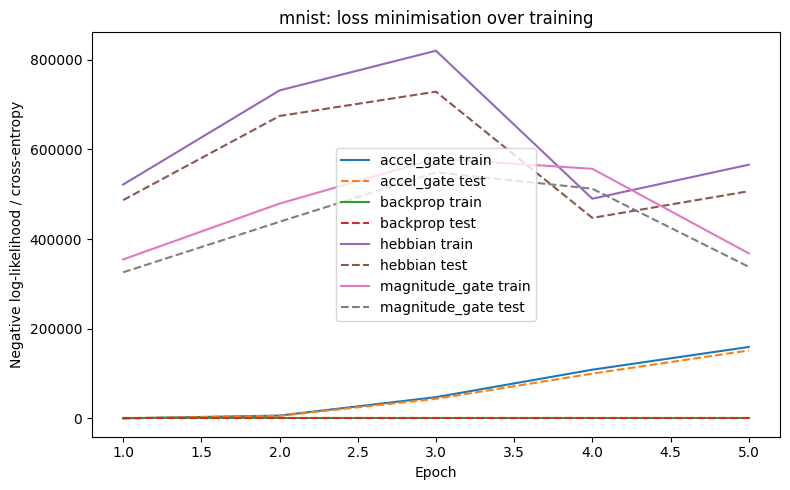

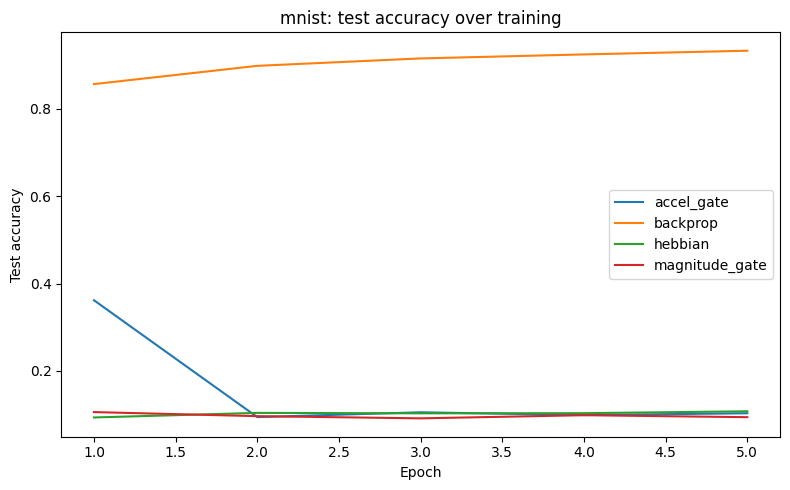

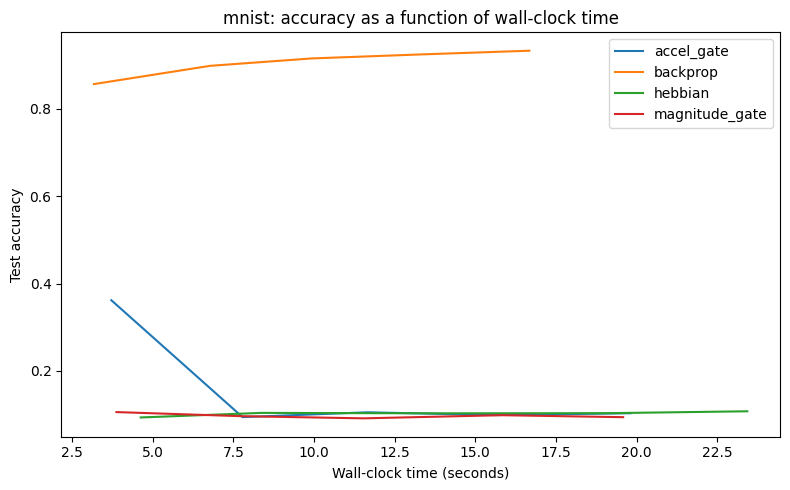

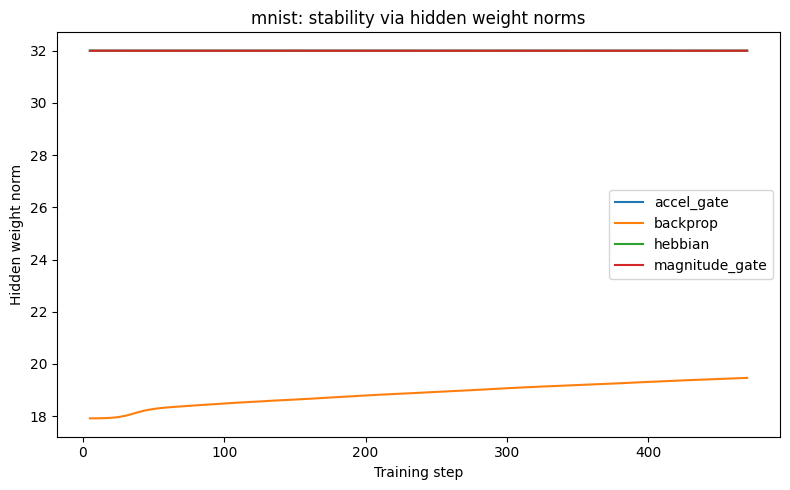

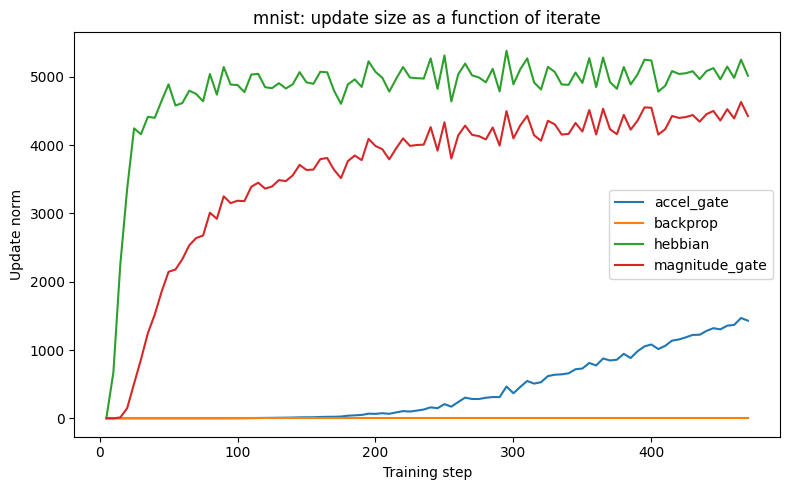

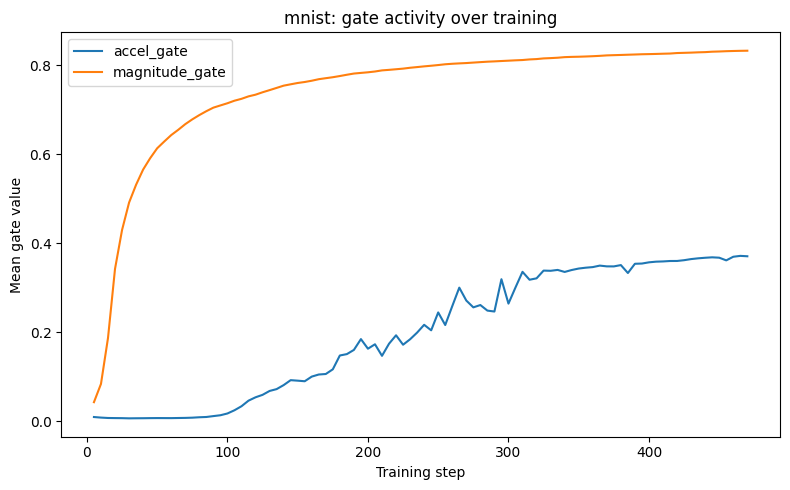

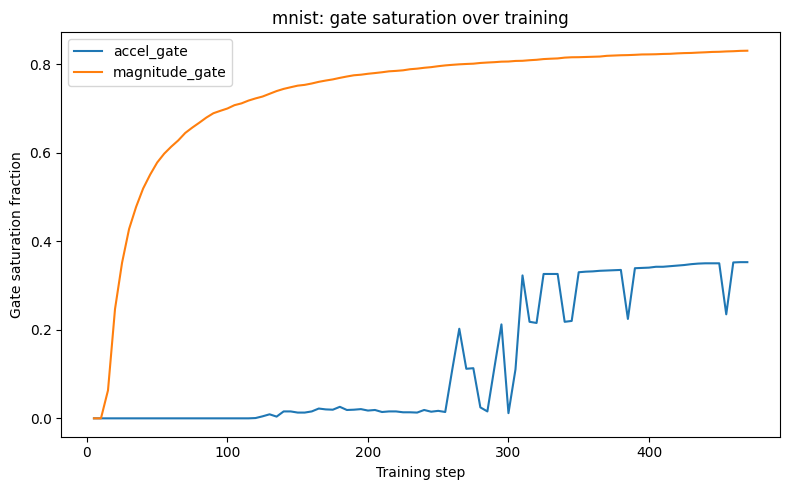

In [ ]:

plot_learning_analysis("mnist", batch_history_df, eval_history_df, include_gate_plots=True)


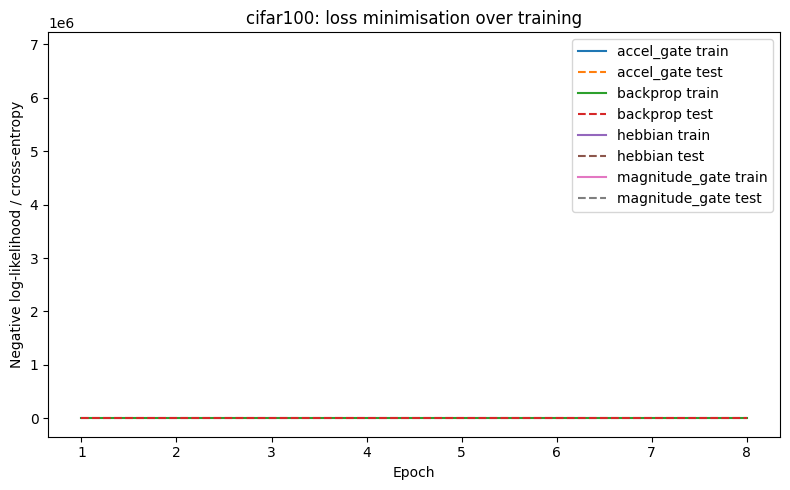

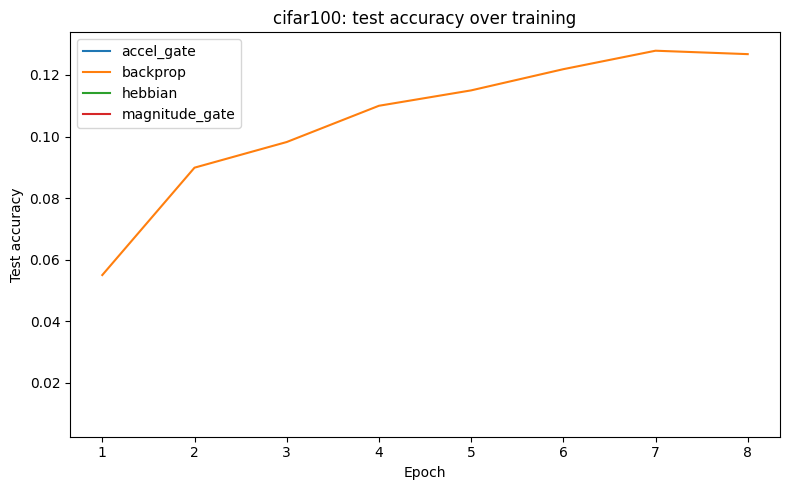

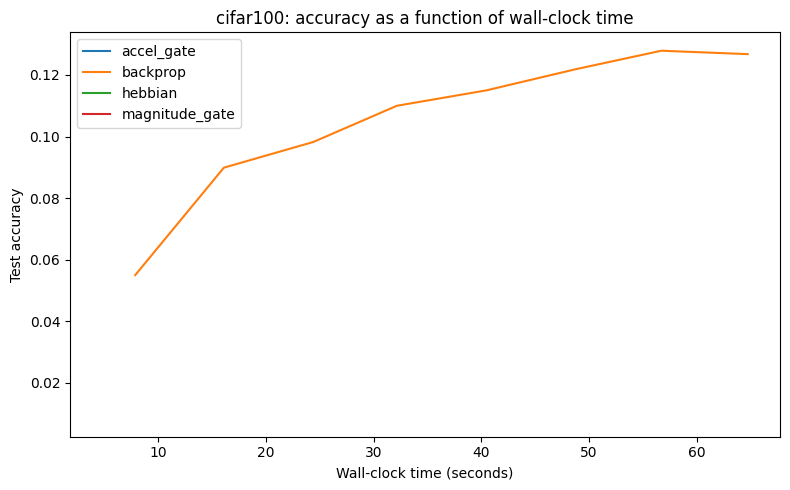

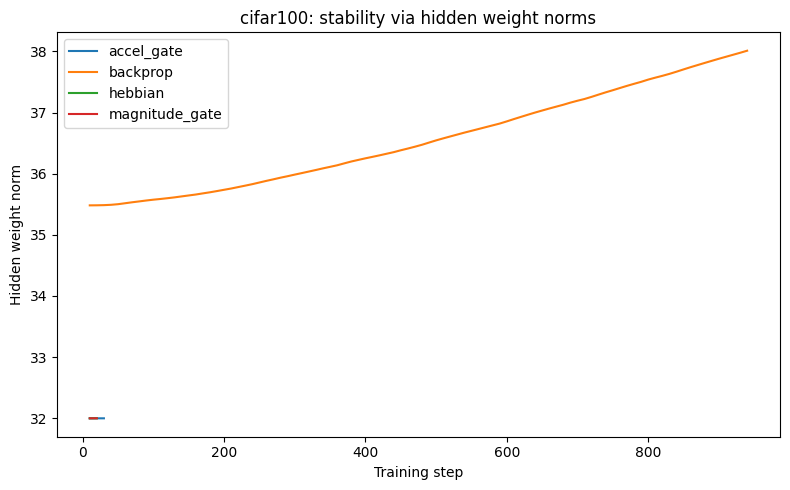

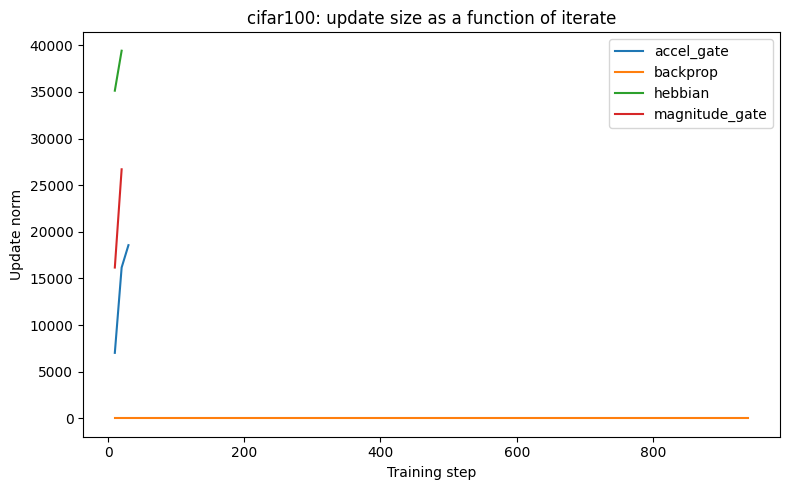

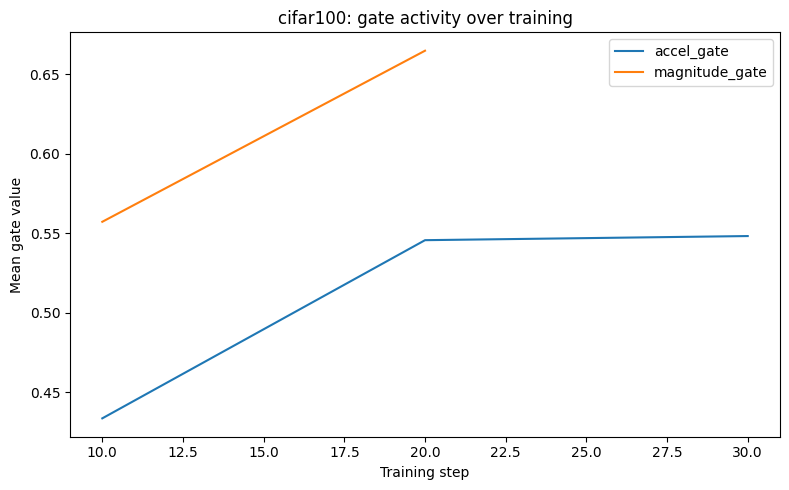

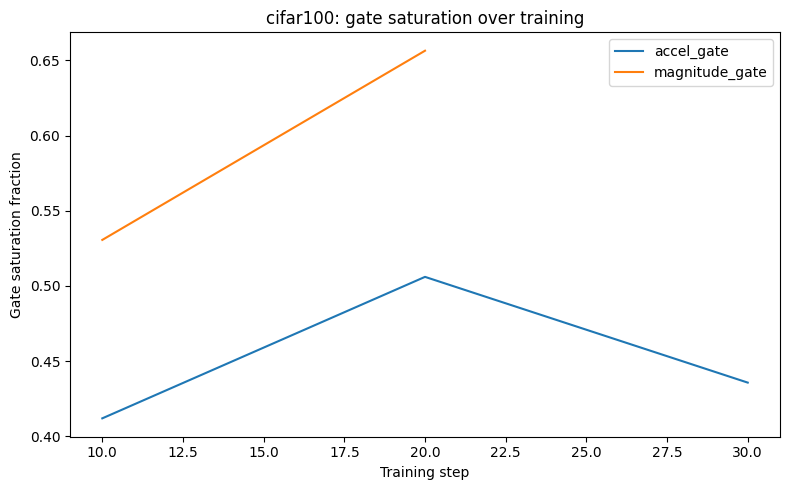

In [ ]:

plot_learning_analysis("cifar100", batch_history_df, eval_history_df, include_gate_plots=True)


Per feedback, we inspect weight distributions, as well as matrices and feature maps, to identify that our gates do not reasonably change vanilla Hebbian behavior.

In [ ]:
DIAG_DATASET = "mnist"          # Try "cifar100" after the MNIST pass.
DIAG_RULES = list(rules)         # e.g. ["hebbian", "accel_gate", "magnitude_gate", "backprop"]
DIAG_SEED = seeds[0] if len(seeds) > 0 else 0

DIAG_TRAIN_SUBSET = image_config[DIAG_DATASET]["train_subset"]
DIAG_TEST_SUBSET = image_config[DIAG_DATASET]["test_subset"]
DIAG_EPOCHS = image_config[DIAG_DATASET]["epochs"]

DIAG_MAX_ACTIVATION_BATCHES = 8
DIAG_MAX_PCA_POINTS = 800

In [ ]:
def train_one_diagnostic_model(
    *,
    dataset_name: str,
    rule: str,
    seed: int,
    train_loader: DataLoader,
    test_loader: DataLoader,
    input_dim: int,
    num_classes: int,
    device: torch.device,
    hidden_dims: list[int],
    epochs: int,
    lr_hidden: float,
    lr_out: float,
    alpha: float,
    g_max: float,
    oja_decay: float,
    momentum: float,
):
    """Train one model and return the fitted model, epoch diagnostics, and final metrics."""
    set_seed(seed)
    model = MLP(input_dim, hidden_dims, num_classes).to(device)

    if rule == "backprop":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr_out, momentum=momentum)
        rule_states = None
    else:
        optimizer = torch.optim.SGD(model.out.parameters(), lr=lr_out, momentum=momentum)
        rule_states = init_rule_states(model, device)

    epoch_rows = []
    max_update_norm = 0.0
    final_gate_mean = None
    final_gate_sat = None

    for epoch in range(epochs):
        model.train()
        train_loss_sum = 0.0
        train_correct = 0
        train_count = 0

        for xb, yb in train_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)

            feats, pres, posts = model.features(xb)
            logits = model.out(feats)
            loss = F.cross_entropy(logits, yb)

            if not torch.isfinite(loss):
                print(f"Stopping early for {rule}: non-finite loss at epoch {epoch + 1}.")
                break

            if rule == "backprop":
                loss.backward()
                optimizer.step()
                local_update_norm = 0.0
                gate_mean = None
                gate_sat = None
            else:
                loss.backward()
                optimizer.step()
                gate_mean, gate_sat, local_update_norm = update_hidden_layers_local(
                    model=model,
                    pre_acts=[p.detach().view(p.size(0), -1) for p in pres],
                    post_acts=[p.detach() for p in posts],
                    states=rule_states,
                    rule=rule,
                    lr_hidden=lr_hidden,
                    alpha=alpha,
                    g_max=g_max,
                    oja_decay=oja_decay,
                )
                max_update_norm = max(max_update_norm, local_update_norm)
                final_gate_mean = gate_mean
                final_gate_sat = gate_sat

            with torch.no_grad():
                train_loss_sum += float(loss.item()) * yb.size(0)
                train_correct += int((logits.argmax(dim=1) == yb).sum().item())
                train_count += yb.size(0)

        train_nll = train_loss_sum / max(train_count, 1)
        train_acc = train_correct / max(train_count, 1)
        test_nll, test_acc = evaluate_model(model, test_loader, device)
        epoch_rows.append(
            {
                "dataset": dataset_name,
                "rule": rule,
                "seed": seed,
                "epoch": epoch + 1,
                "train_nll": train_nll,
                "train_acc": train_acc,
                "test_nll": test_nll,
                "test_acc": test_acc,
                "last_gate_mean": final_gate_mean,
                "last_gate_saturation_frac": final_gate_sat,
                "max_update_norm": max_update_norm,
            }
        )
        print(
            f"{dataset_name} | {rule:>14s} | epoch {epoch + 1:02d}/{epochs}: "
            f"train acc={train_acc:.3f}, test acc={test_acc:.3f}, test nll={test_nll:.3f}"
        )

    model.eval()
    epoch_df = pd.DataFrame(epoch_rows)
    return model, epoch_df


def run_weight_diagnostic_pass():
    cfg = image_config[DIAG_DATASET]
    train_loader, test_loader, input_dim, num_classes = make_image_loaders(
        DIAG_DATASET,
        batch_size=cfg["batch_size"],
        train_subset=DIAG_TRAIN_SUBSET,
        test_subset=DIAG_TEST_SUBSET,
    )

    models = {}
    history_frames = []
    for rule in DIAG_RULES:
        model, hist = train_one_diagnostic_model(
            dataset_name=DIAG_DATASET,
            rule=rule,
            seed=DIAG_SEED,
            train_loader=train_loader,
            test_loader=test_loader,
            input_dim=input_dim,
            num_classes=num_classes,
            device=device,
            hidden_dims=cfg["hidden_dims"],
            epochs=DIAG_EPOCHS,
            lr_hidden=cfg["lr_hidden"],
            lr_out=cfg["lr_out"],
            alpha=cfg["alpha"],
            g_max=cfg["g_max"],
            oja_decay=cfg["oja_decay"],
            momentum=cfg["momentum"],
        )
        models[rule] = model
        history_frames.append(hist)

    hist_df = pd.concat(history_frames, ignore_index=True) if history_frames else pd.DataFrame()
    return models, hist_df, train_loader, test_loader, input_dim, num_classes


diagnostic_models, diagnostic_history_df, diagnostic_train_loader, diagnostic_test_loader, diagnostic_input_dim, diagnostic_num_classes = run_weight_diagnostic_pass()
display(diagnostic_history_df)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


mnist |        hebbian | epoch 01/5: train acc=0.100, test acc=0.102, test nll=468680.274
mnist |        hebbian | epoch 02/5: train acc=0.099, test acc=0.117, test nll=777606.922
mnist |        hebbian | epoch 03/5: train acc=0.102, test acc=0.103, test nll=684493.454
mnist |        hebbian | epoch 04/5: train acc=0.101, test acc=0.102, test nll=506697.776
mnist |        hebbian | epoch 05/5: train acc=0.097, test acc=0.096, test nll=601029.458
mnist |     accel_gate | epoch 01/5: train acc=0.612, test acc=0.536, test nll=1.488
mnist |     accel_gate | epoch 02/5: train acc=0.140, test acc=0.089, test nll=7522.001
mnist |     accel_gate | epoch 03/5: train acc=0.096, test acc=0.102, test nll=36276.592
mnist |     accel_gate | epoch 04/5: train acc=0.096, test acc=0.097, test nll=66631.443
mnist |     accel_gate | epoch 05/5: train acc=0.099, test acc=0.087, test nll=151227.528
mnist | magnitude_gate | epoch 01/5: train acc=0.117, test acc=0.089, test nll=250542.923
mnist | magnitude_g

/tmp/ipykernel_21923/3127744697.py:145: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  hist_df = pd.concat(history_frames, ignore_index=True) if history_frames else pd.DataFrame()


,dataset,rule,seed,epoch,train_nll,train_acc,test_nll,test_acc,last_gate_mean,last_gate_saturation_frac,max_update_norm
0,mnist,hebbian,0,1,416468.416441,0.100417,468680.274000,0.1025,NaN,NaN,5402.196289
1,mnist,hebbian,0,2,716707.951167,0.098750,777606.922000,0.1170,NaN,NaN,5720.824219
2,mnist,hebbian,0,3,658861.997500,0.102083,684493.454000,0.1035,NaN,NaN,5720.824219
3,mnist,hebbian,0,4,699060.949833,0.101000,506697.776000,0.1025,NaN,NaN,5720.824219
4,mnist,hebbian,0,5,735935.216667,0.097167,601029.458000,0.0960,NaN,NaN,5720.824219
5,mnist,accel_gate,0,1,1.688618,0.611750,1.487575,0.5365,0.011426,0.000000,0.824060
6,mnist,accel_gate,0,2,1763.139431,0.140250,7522.001469,0.0890,0.158118,0.021484,47.999256
7,mnist,accel_gate,0,3,17182.299792,0.096083,36276.591875,0.1025,0.326047,0.314453,406.854858
8,mnist,accel_gate,0,4,71022.724458,0.096417,66631.443500,0.0970,0.352958,0.339844,947.390076
9,mnist,accel_gate,0,5,132889.003187,0.099250,151227.528000,0.0875,0.377499,0.359375,1594.061279


In [ ]:
def _as_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def named_weight_arrays(model: MLP):
    arrays = []
    for i, layer in enumerate(model.hidden_layers):
        arrays.append((f"hidden_{i + 1}", _as_numpy(layer.weight)))
    arrays.append(("readout", _as_numpy(model.out.weight)))
    if model.out.bias is not None:
        arrays.append(("readout_bias", _as_numpy(model.out.bias).reshape(1, -1)))
    return arrays


def summarise_weight_arrays(models: dict[str, MLP]) -> pd.DataFrame:
    rows = []
    for rule, model in models.items():
        for layer_name, w in named_weight_arrays(model):
            flat = w.reshape(-1)
            row_norms = np.linalg.norm(w.reshape(w.shape[0], -1), axis=1)
            rows.append(
                {
                    "rule": rule,
                    "layer": layer_name,
                    "shape": str(tuple(w.shape)),
                    "mean": float(np.mean(flat)),
                    "std": float(np.std(flat)),
                    "min": float(np.min(flat)),
                    "q01": float(np.quantile(flat, 0.01)),
                    "median": float(np.median(flat)),
                    "q99": float(np.quantile(flat, 0.99)),
                    "max": float(np.max(flat)),
                    "frac_positive": float(np.mean(flat > 0)),
                    "frac_near_zero_abs_lt_1e_minus_4": float(np.mean(np.abs(flat) < 1e-4)),
                    "mean_row_norm": float(np.mean(row_norms)),
                    "std_row_norm": float(np.std(row_norms)),
                    "min_row_norm": float(np.min(row_norms)),
                    "max_row_norm": float(np.max(row_norms)),
                }
            )
    return pd.DataFrame(rows)


weight_summary_df = summarise_weight_arrays(diagnostic_models)
display(weight_summary_df)


def plot_weight_histograms(models: dict[str, MLP], bins: int = 80):
    for layer_name in [name for name, _ in named_weight_arrays(next(iter(models.values())))] :
        plt.figure(figsize=(8, 5))
        for rule, model in models.items():
            w = dict(named_weight_arrays(model))[layer_name].reshape(-1)
            plt.hist(w, bins=bins, histtype="step", density=True, label=rule)
        plt.xlabel("Weight value")
        plt.ylabel("Density")
        plt.title(f"{DIAG_DATASET}: distribution of {layer_name} weights")
        plt.legend()
        plt.tight_layout()
        plt.show()


def plot_row_norms(models: dict[str, MLP], bins: int = 60):
    for layer_name in [name for name, _ in named_weight_arrays(next(iter(models.values()))) if name != "readout_bias"]:
        plt.figure(figsize=(8, 5))
        for rule, model in models.items():
            w = dict(named_weight_arrays(model))[layer_name]
            row_norms = np.linalg.norm(w.reshape(w.shape[0], -1), axis=1)
            plt.hist(row_norms, bins=bins, histtype="step", density=True, label=rule)
        plt.xlabel("Row norm")
        plt.ylabel("Density")
        plt.title(f"{DIAG_DATASET}: row-norm distribution for {layer_name}")
        plt.legend()
        plt.tight_layout()
        plt.show()


plot_weight_histograms(diagnostic_models)
plot_row_norms(diagnostic_models)

In [ ]:
def _matrix_view(w: np.ndarray, max_rows: int = 256, max_cols: int = 256) -> np.ndarray:
    """Evenly subsample a large weight matrix so imshow remains readable."""
    w2 = w.reshape(w.shape[0], -1)
    row_idx = np.linspace(0, w2.shape[0] - 1, min(max_rows, w2.shape[0])).astype(int)
    col_idx = np.linspace(0, w2.shape[1] - 1, min(max_cols, w2.shape[1])).astype(int)
    return w2[np.ix_(row_idx, col_idx)]


def plot_weight_matrix_views(models: dict[str, MLP], max_rows: int = 256, max_cols: int = 256):
    for rule, model in models.items():
        for layer_name, w in named_weight_arrays(model):
            if layer_name == "readout_bias":
                continue
            view = _matrix_view(w, max_rows=max_rows, max_cols=max_cols)
            plt.figure(figsize=(7, 5))
            plt.imshow(view, aspect="auto")
            plt.colorbar(label="Weight value")
            plt.xlabel("Input/unit index, subsampled if needed")
            plt.ylabel("Output/unit index, subsampled if needed")
            plt.title(f"{DIAG_DATASET}: {rule}, {layer_name} weight matrix")
            plt.tight_layout()
            plt.show()


plot_weight_matrix_views(diagnostic_models)

In [ ]:
def _normalise_for_display(img: np.ndarray) -> np.ndarray:
    lo, hi = np.quantile(img, [0.01, 0.99])
    if hi <= lo:
        return np.zeros_like(img)
    return np.clip((img - lo) / (hi - lo), 0.0, 1.0)


def first_layer_filter_images(model: MLP, dataset_name: str, n_filters: int = 24, sort_by: str = "norm"):
    w = _as_numpy(model.hidden_layers[0].weight)
    if sort_by == "norm":
        order = np.argsort(np.linalg.norm(w.reshape(w.shape[0], -1), axis=1))[::-1]
    elif sort_by == "variance":
        order = np.argsort(np.var(w.reshape(w.shape[0], -1), axis=1))[::-1]
    else:
        order = np.arange(w.shape[0])
    order = order[: min(n_filters, len(order))]

    images = []
    for idx in order:
        filt = w[idx]
        if dataset_name.lower() == "mnist":
            img = filt.reshape(28, 28)
            images.append(_normalise_for_display(img))
        elif dataset_name.lower() == "cifar100":
            img = filt.reshape(3, 32, 32).transpose(1, 2, 0)
            images.append(_normalise_for_display(img))
        else:
            raise ValueError(f"No image reshape rule for {dataset_name}")
    return images, order


def plot_first_layer_filters(models: dict[str, MLP], dataset_name: str, n_filters: int = 24, sort_by: str = "norm"):
    for rule, model in models.items():
        images, order = first_layer_filter_images(model, dataset_name, n_filters=n_filters, sort_by=sort_by)
        n = len(images)
        ncols = min(8, n)
        nrows = int(math.ceil(n / ncols))
        plt.figure(figsize=(1.6 * ncols, 1.8 * nrows))
        for j, img in enumerate(images):
            ax = plt.subplot(nrows, ncols, j + 1)
            ax.imshow(img)
            ax.set_title(str(order[j]), fontsize=8)
            ax.axis("off")
        plt.suptitle(f"{DIAG_DATASET}: {rule}, first-layer filters sorted by {sort_by}")
        plt.tight_layout()
        plt.show()


plot_first_layer_filters(diagnostic_models, DIAG_DATASET, n_filters=24, sort_by="norm")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


,rule,layer,mean_activation,std_activation,median_activation,frac_exact_zero,dead_unit_frac_active_lt_1_percent,nearly_constant_unit_frac_std_lt_1e_minus_4,mean_unit_active_frac,std_unit_mean_activation
0,hebbian,hidden_1,5.496481,1.733536,5.386618,0.002905,0.001953,0.000000,0.997095,0.297909
1,hebbian,hidden_2,133.485229,89.205566,150.143387,0.242188,0.242188,0.242188,0.757812,75.461975
2,accel_gate,hidden_1,1.919902,2.556691,0.381777,0.307714,0.002930,0.000000,0.692286,2.372468
3,accel_gate,hidden_2,70.191826,50.787090,81.555084,0.281200,0.277344,0.269531,0.718800,43.908024
4,magnitude_gate,hidden_1,4.769046,2.459371,5.048590,0.108870,0.002930,0.000000,0.891130,1.876103
5,magnitude_gate,hidden_2,129.401108,80.739021,143.723694,0.210938,0.210938,0.210938,0.789062,66.905098
6,backprop,hidden_1,0.127624,0.208914,0.000000,0.524751,0.003906,0.000000,0.475249,0.090893
7,backprop,hidden_2,0.335078,0.503247,0.089502,0.411736,0.003906,0.000000,0.588264,0.256561


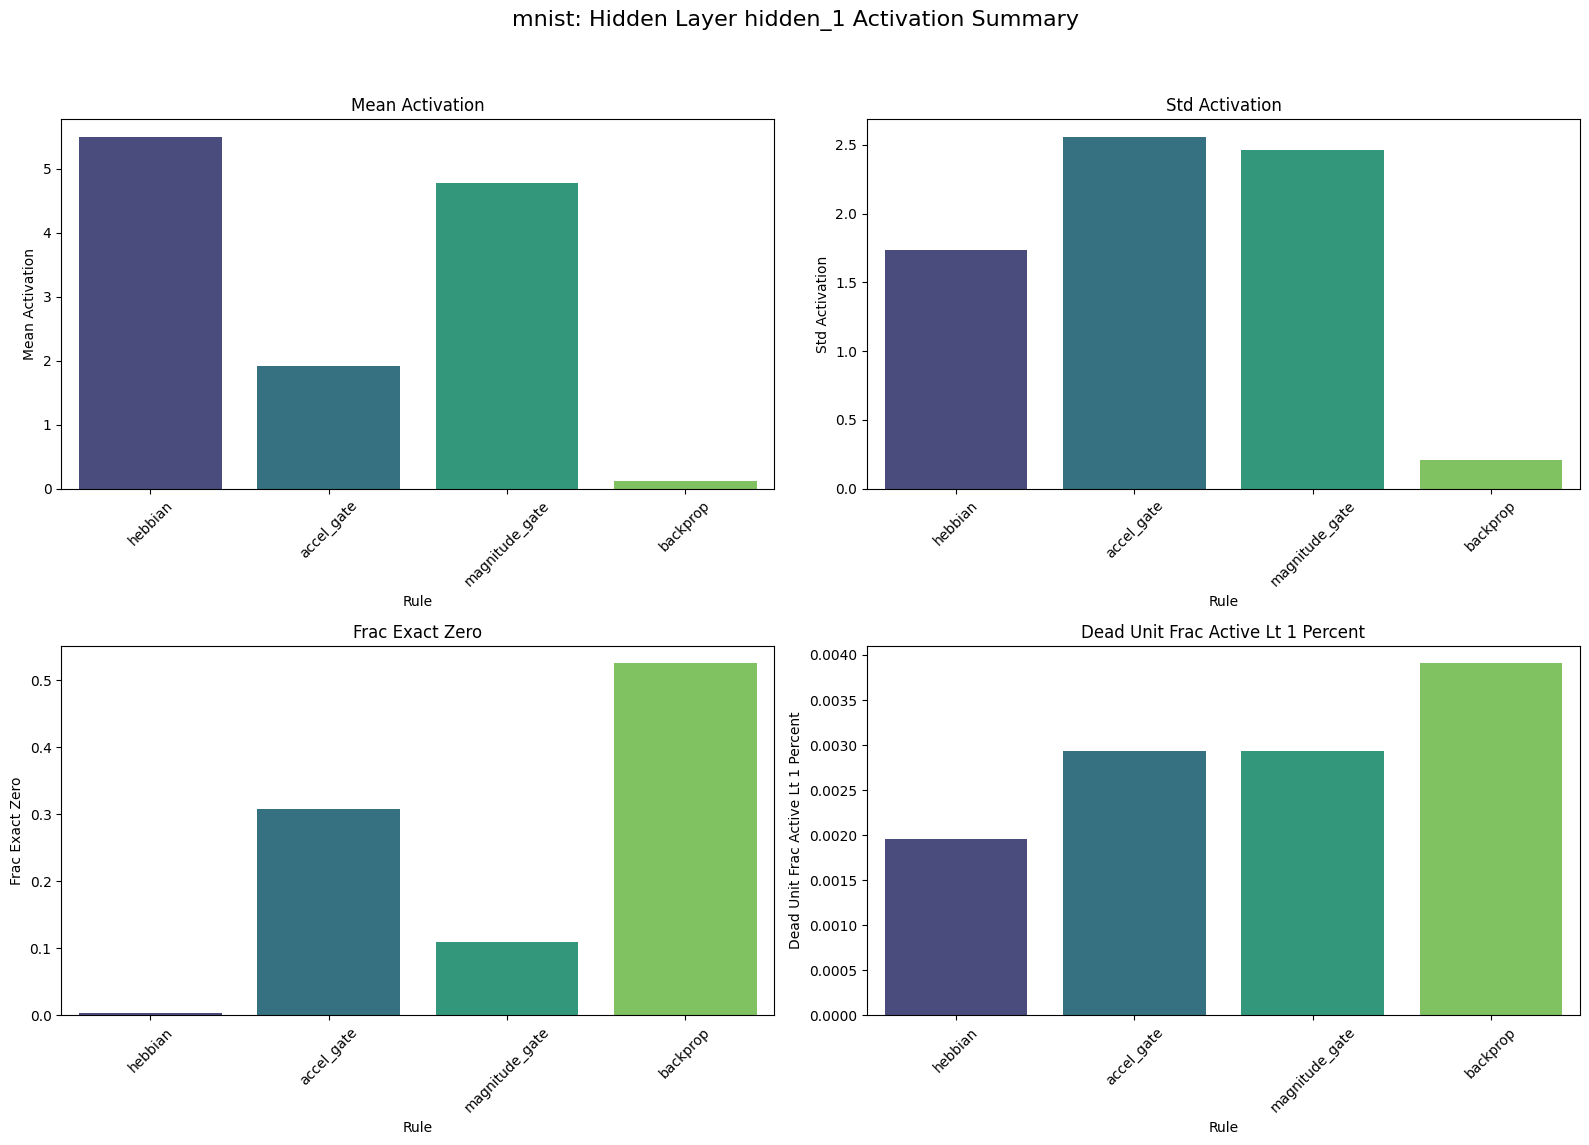

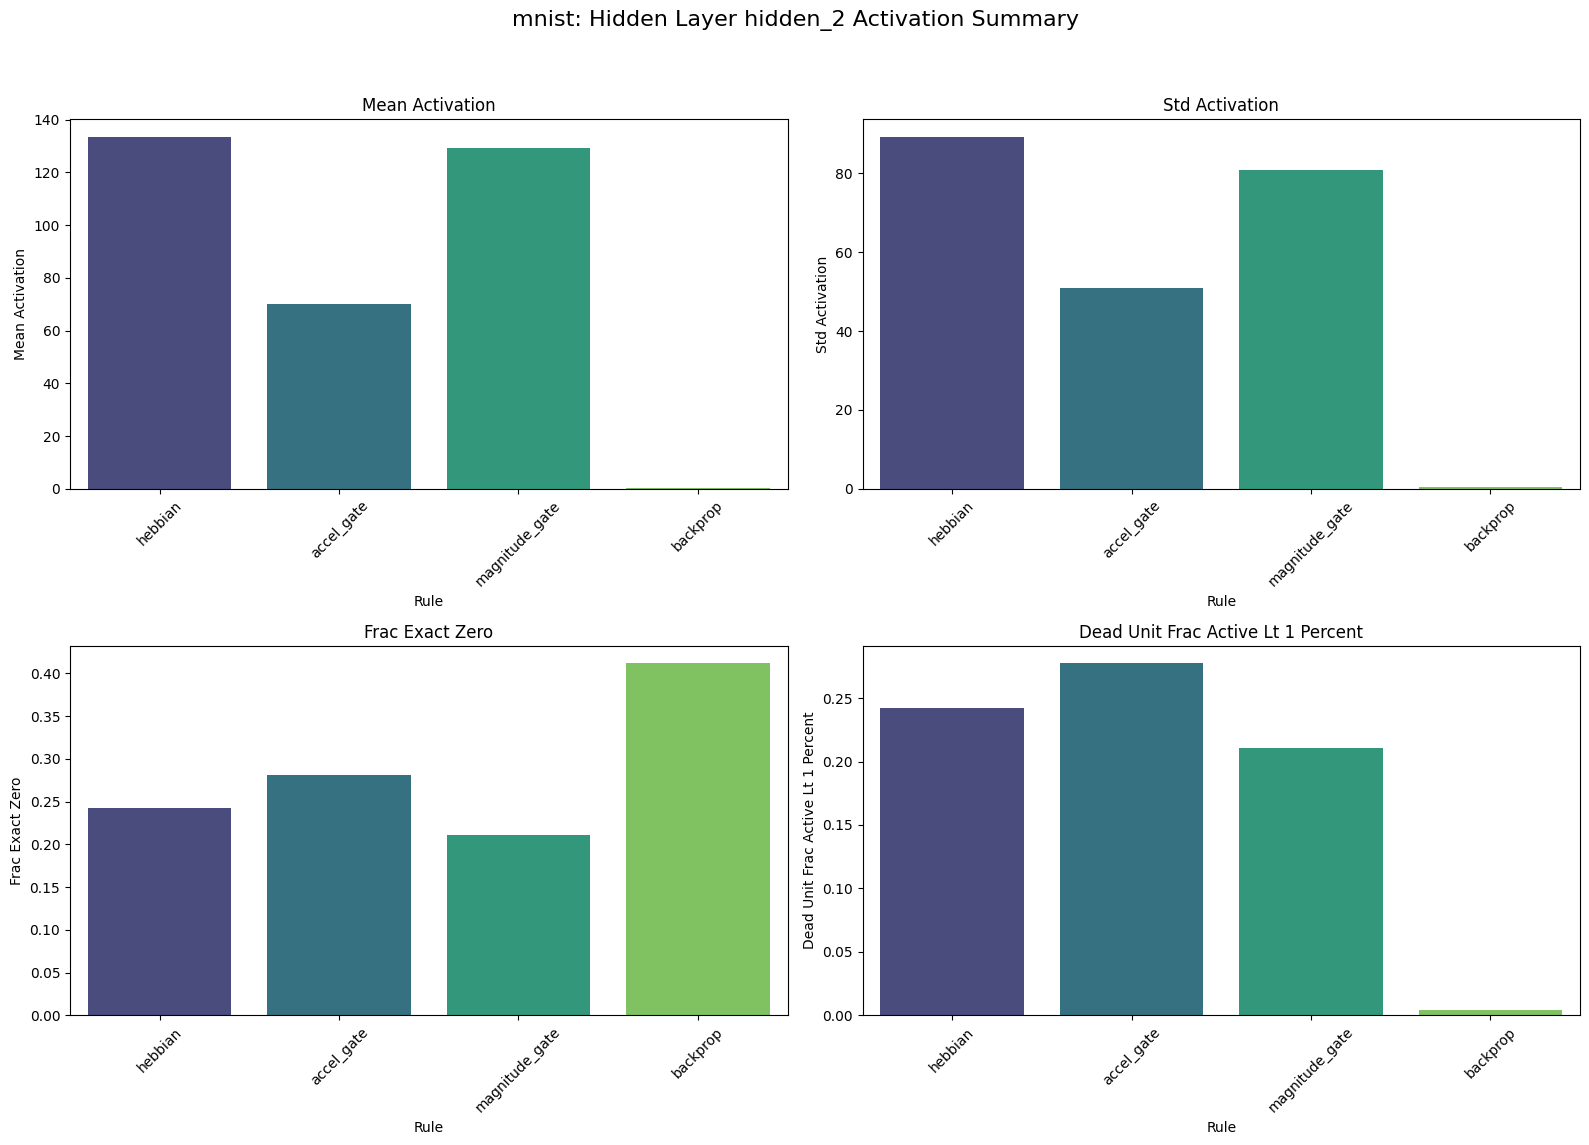

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


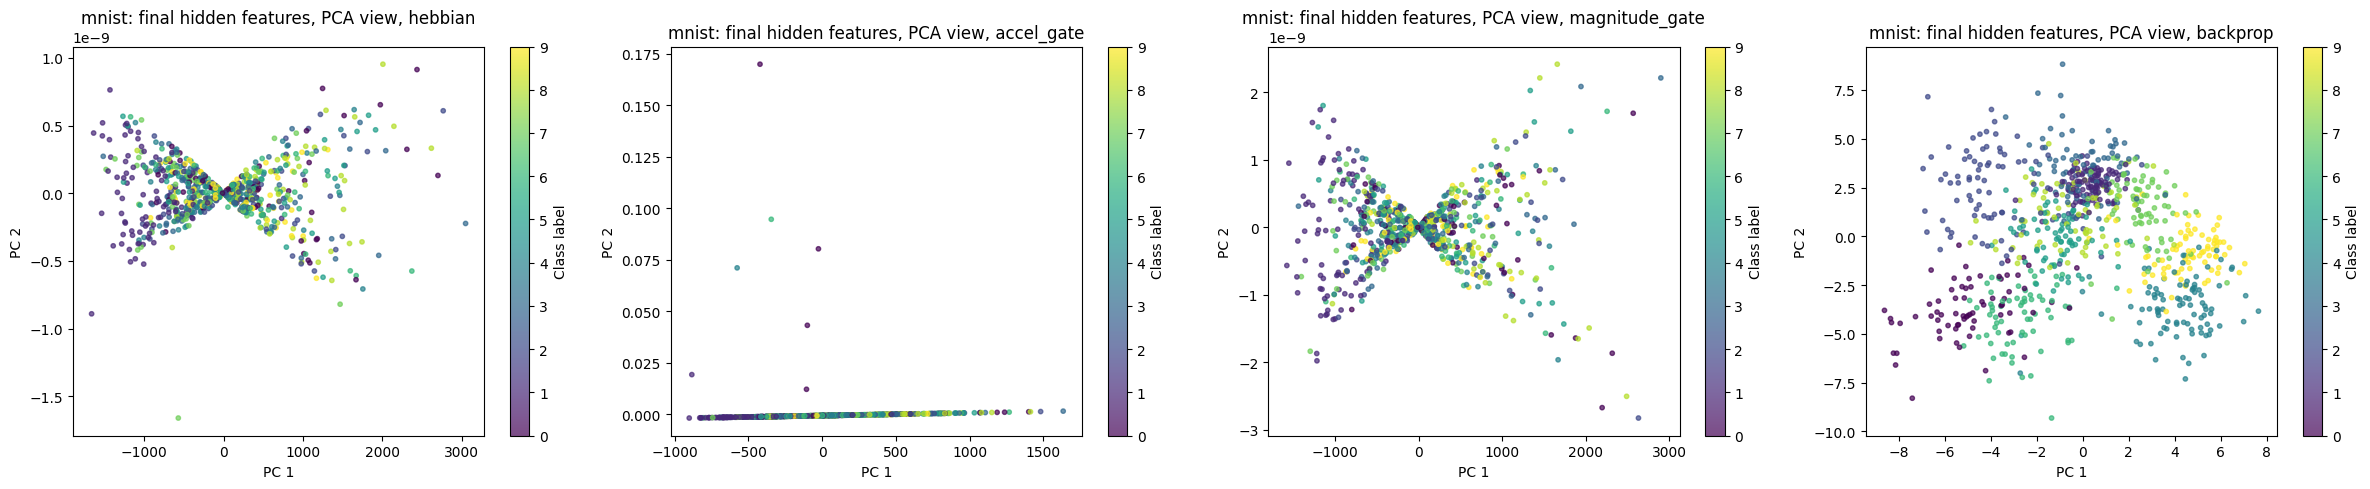

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_activation_summary(df: pd.DataFrame):
    unique_layers = df['layer'].unique()
    metrics_to_plot = [
        'mean_activation',
        'std_activation',
        'frac_exact_zero',
        'dead_unit_frac_active_lt_1_percent'
    ]

    for layer in unique_layers:
        layer_df = df[df['layer'] == layer].copy()

        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle(f'{DIAG_DATASET}: Hidden Layer {layer} Activation Summary', fontsize=16)
        axes = axes.flatten()

        for i, metric in enumerate(metrics_to_plot):
            ax = axes[i]
            sns.barplot(x='rule', y=metric, data=layer_df, ax=ax, palette='viridis', hue='rule', legend=False)
            ax.set_title(metric.replace('_', ' ').title())
            ax.set_xlabel('Rule')
            ax.set_ylabel(metric.replace('_', ' ').title())
            ax.tick_params(axis='x', rotation=45)

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

activation_summary_df = pd.concat(
    [
        hidden_activation_summary(model, diagnostic_test_loader, max_batches=DIAG_MAX_ACTIVATION_BATCHES).assign(rule=rule)
        for rule, model in diagnostic_models.items()
    ],
    ignore_index=True,
)
activation_summary_df = activation_summary_df[["rule"] + [c for c in activation_summary_df.columns if c != "rule"]]
display(activation_summary_df)

plot_activation_summary(activation_summary_df)


@torch.no_grad()
def collect_final_features(model: MLP, loader: DataLoader, max_points: int = 800):
    model.eval()
    feats_all = []
    y_all = []
    total = 0
    for xb, yb in loader:
        xb = xb.to(device)
        feats, _, _ = model.features(xb)
        feats_all.append(feats.detach().cpu().numpy())
        y_all.append(yb.numpy())
        total += xb.size(0)
        if total >= max_points:
            break
    feats = np.concatenate(feats_all, axis=0)[:max_points]
    labels = np.concatenate(y_all, axis=0)[:max_points]
    return feats, labels


def plot_final_feature_pca(models: dict[str, MLP], loader: DataLoader, max_points: int = 800):
    num_rules = len(models)
    if num_rules == 0:
        return

    # Determine optimal grid size for subplots
    ncols = min(num_rules, 4)  # Max 4 columns
    nrows = (num_rules + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6, nrows * 5), squeeze=False)
    axes = axes.flatten()

    for i, (rule, model) in enumerate(models.items()):
        feats, labels = collect_final_features(model, loader, max_points=max_points)
        coords = PCA(n_components=2).fit_transform(feats)

        ax = axes[i]
        scatter = ax.scatter(coords[:, 0], coords[:, 1], c=labels, s=10, alpha=0.7, cmap='viridis')
        ax.set_xlabel('PC 1')
        ax.set_ylabel('PC 2')
        ax.set_title(f'{DIAG_DATASET}: final hidden features, PCA view, {rule}')
        fig.colorbar(scatter, ax=ax, label='Class label')

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


plot_final_feature_pca(diagnostic_models, diagnostic_test_loader, max_points=DIAG_MAX_PCA_POINTS)